## JSC370 Midterm Project

## 1. Setup

In [2]:
import requests
import pandas as pd
import numpy as np
import time

## 2. Data Collection — WHO GHO API

In [3]:
WHO_BASE = "https://ghoapi.azureedge.net/api/"

def fetch_who_indicator(indicator_code, spatial_type="COUNTRY"):
    """Fetch all country-level data for a WHO GHO indicator."""
    url = f"{WHO_BASE}{indicator_code}"
    params = {"$filter": f"SpatialDimType eq '{spatial_type}'"}
    
    all_records = []
    while url:
        resp = requests.get(url, params=params)
        resp.raise_for_status()
        data = resp.json()
        all_records.extend(data.get("value", []))
        url = data.get("@odata.nextLink", None)
        params = {}  # nextLink already has params
    
    df = pd.DataFrame(all_records)
    return df

In [4]:
df_ncd_mort = fetch_who_indicator("NCDMORT3070")
print(f"NCD mortality: {df_ncd_mort.shape}")
df_ncd_mort.head(3)

NCD mortality: (12210, 25)


,Id,IndicatorCode,SpatialDimType,SpatialDim,TimeDimType,ParentLocationCode,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
0,7284124,NCDMORT3070,COUNTRY,ECU,YEAR,AMR,Americas,SEX,2001,SEX_FMLE,...,None,14.2 [11.3-16.9],14.2,11.3,16.9,None,2024-12-18T14:54:42.07+01:00,2001,2001-01-01T00:00:00+01:00,2001-12-31T00:00:00+01:00
1,7284181,NCDMORT3070,COUNTRY,BWA,YEAR,AFR,Africa,SEX,2005,SEX_FMLE,...,None,12.5 [6.3-22.1],12.5,6.3,22.1,None,2024-12-18T14:54:42.07+01:00,2005,2005-01-01T00:00:00+01:00,2005-12-31T00:00:00+01:00
2,7285026,NCDMORT3070,COUNTRY,JAM,YEAR,AMR,Americas,SEX,2012,SEX_MLE,...,None,16.0 [13.2-18.6],16.0,13.2,18.6,None,2024-12-18T14:54:42.07+01:00,2012,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00


In [5]:
indicators = {
    "WHOSIS_000001": "life_expectancy",
    "WHS2_131": "tb_incidence",
    "MALARIA_EST_DEATHS": "malaria_deaths",
    "HIV_0000000026": "hiv_new_infections",
    "NCDMORT3070": "ncd_mortality_30_70"
}

who_dfs = {}
for code, name in indicators.items():
    if code == "NCDMORT3070":
        who_dfs[name] = df_ncd_mort
        continue
    print(f"Fetching {name} ({code})...")
    who_dfs[name] = fetch_who_indicator(code)
    print(f"  → {who_dfs[name].shape}")
    time.sleep(1)

print("\nAll WHO indicators fetched.")

Fetching life_expectancy (WHOSIS_000001)...
  → (12210, 25)
Fetching tb_incidence (WHS2_131)...
  → (12210, 25)
Fetching malaria_deaths (MALARIA_EST_DEATHS)...
  → (2723, 25)
Fetching hiv_new_infections (HIV_0000000026)...
  → (4850, 25)

All WHO indicators fetched.


In [6]:
for name, df in who_dfs.items():
    print(f"\n--- {name} ---")
    print(f"Years: {sorted(df['TimeDim'].dropna().unique())}")
    print(f"Dim1 values: {df['Dim1'].dropna().unique()}")
    print(f"Countries: {df['SpatialDim'].nunique()}")


--- life_expectancy ---
Years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Dim1 values: ['SEX_FMLE' 'SEX_BTSX' 'SEX_MLE']
Countries: 185

--- tb_incidence ---
Years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Dim1 values: ['SEX_MLE' 'SEX_BTSX' 'SEX_FMLE']
Countries: 185

--- malaria_deaths ---
Years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Dim1 values: []
Countries: 110

--- hiv_new_infections ---
Years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Dim1 values: []
Countries: 194

--- ncd_mortality_30_70 ---
Years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013

In [7]:
def clean_who(df, value_col_name, has_sex=True):
    """Filter to both sexes, keep country/year/value."""
    d = df.copy()
    if has_sex and "Dim1" in d.columns:
        d = d[d["Dim1"] == "SEX_BTSX"]
    d = d[["SpatialDim", "ParentLocationCode", "ParentLocation", "TimeDim", "NumericValue"]].copy()
    d = d.rename(columns={
        "SpatialDim": "country_code",
        "ParentLocationCode": "who_region_code",
        "ParentLocation": "who_region",
        "TimeDim": "year",
        "NumericValue": value_col_name
    })
    d["year"] = d["year"].astype(int)
    return d

df_life = clean_who(who_dfs["life_expectancy"], "life_expectancy")
df_tb = clean_who(who_dfs["tb_incidence"], "tb_incidence_per100k")
df_mal = clean_who(who_dfs["malaria_deaths"], "malaria_deaths", has_sex=False)
df_hiv = clean_who(who_dfs["hiv_new_infections"], "hiv_new_infections_per1000", has_sex=False)
df_ncd = clean_who(who_dfs["ncd_mortality_30_70"], "ncd_mortality_pct")

who_merged = df_life.merge(df_tb, on=["country_code", "who_region_code", "who_region", "year"], how="outer")
who_merged = who_merged.merge(df_mal, on=["country_code", "who_region_code", "who_region", "year"], how="outer")
who_merged = who_merged.merge(df_hiv, on=["country_code", "who_region_code", "who_region", "year"], how="outer")
who_merged = who_merged.merge(df_ncd, on=["country_code", "who_region_code", "who_region", "year"], how="outer")

print(f"WHO merged: {who_merged.shape}")
print(f"Countries: {who_merged['country_code'].nunique()}")
print(f"Years: {who_merged['year'].min()} - {who_merged['year'].max()}")
print(f"\nMissing values:\n{who_merged.isnull().sum()}")
who_merged.head(3)

WHO merged: (4941, 9)
Countries: 198
Years: 2000 - 2024

Missing values:
country_code                     0
who_region_code                  0
who_region                       0
year                             0
life_expectancy                871
tb_incidence_per100k           871
malaria_deaths                2218
hiv_new_infections_per1000    1427
ncd_mortality_pct              871
dtype: int64


,country_code,who_region_code,who_region,year,life_expectancy,tb_incidence_per100k,malaria_deaths,hiv_new_infections_per1000,ncd_mortality_pct
0,AFG,EMR,Eastern Mediterranean,2000,53.823326,1120.545410,965.0,500.0,43.2
1,AFG,EMR,Eastern Mediterranean,2001,53.910188,1130.776611,965.0,500.0,43.5
2,AFG,EMR,Eastern Mediterranean,2002,55.154478,1118.808350,1133.0,500.0,43.1


## 3. Data Collection — World Bank API

In [8]:
WB_BASE = "https://api.worldbank.org/v2/country/all/indicator/"

def fetch_wb_indicator(indicator_code, start_year=2000, end_year=2024):
    """Fetch World Bank indicator for all countries."""
    all_records = []
    page = 1
    while True:
        params = {
            "format": "json",
            "date": f"{start_year}:{end_year}",
            "per_page": 1000,
            "page": page
        }
        resp = requests.get(f"{WB_BASE}{indicator_code}", params=params)
        resp.raise_for_status()
        data = resp.json()
        
        if len(data) < 2 or not data[1]:
            break
        all_records.extend(data[1])
        
        total_pages = data[0]["pages"]
        if page >= total_pages:
            break
        page += 1
    
    rows = []
    for r in all_records:
        if r["value"] is not None:
            rows.append({
                "country_code": r["countryiso3code"],
                "country_name": r["country"]["value"],
                "year": int(r["date"]),
                "value": float(r["value"])
            })
    return pd.DataFrame(rows)

wb_indicators = {
    "NY.GDP.PCAP.PP.KD": "gdp_per_capita_ppp",
    "SH.XPD.CHEX.GD.ZS": "health_expenditure_pct_gdp",
    "SP.URB.TOTL.IN.ZS": "urban_population_pct",
    "SP.POP.TOTL": "population"
}

wb_dfs = {}
for code, name in wb_indicators.items():
    print(f"Fetching {name} ({code})...")
    wb_dfs[name] = fetch_wb_indicator(code)
    print(f"  → {wb_dfs[name].shape}")
    time.sleep(0.5)

print("\nAll World Bank indicators fetched.")

Fetching gdp_per_capita_ppp (NY.GDP.PCAP.PP.KD)...
  → (6109, 4)
Fetching health_expenditure_pct_gdp (SH.XPD.CHEX.GD.ZS)...
  → (5716, 4)
Fetching urban_population_pct (SP.URB.TOTL.IN.ZS)...
  → (6625, 4)
Fetching population (SP.POP.TOTL)...
  → (6625, 4)

All World Bank indicators fetched.


In [9]:
wb_merged = None
for code, name in wb_indicators.items():
    df = wb_dfs[name].rename(columns={"value": name})
    if wb_merged is None:
        wb_merged = df
    else:
        wb_merged = wb_merged.merge(df[["country_code", "year", name]], 
                                     on=["country_code", "year"], how="outer")

print(f"WB merged: {wb_merged.shape}")
print(f"Countries: {wb_merged['country_code'].nunique()}")
print(f"\nMissing values:\n{wb_merged.isnull().sum()}")
wb_merged.head(3)

WB merged: (12733, 7)
Countries: 262

Missing values:
country_code                    0
country_name                  516
year                            0
gdp_per_capita_ppp            516
health_expenditure_pct_gdp    969
urban_population_pct            0
population                      0
dtype: int64


,country_code,country_name,year,gdp_per_capita_ppp,health_expenditure_pct_gdp,urban_population_pct,population
0,,High income,2000,41052.550749,9.350135,76.124359,1.255696e+09
1,,High income,2000,41052.550749,9.350135,76.124359,3.226682e+08
2,,High income,2000,41052.550749,9.350135,76.124359,2.126560e+09


In [10]:
who_countries = who_merged["country_code"].unique()
print(f"WHO countries: {len(who_countries)}")
wb_clean = wb_merged[wb_merged["country_code"].isin(who_countries)].copy()
wb_clean = wb_clean.drop_duplicates(subset=["country_code", "year"])

print(f"WB after filtering to WHO countries: {wb_clean.shape}")
print(f"Countries: {wb_clean['country_code'].nunique()}")
wb_clean.head(3)

WHO countries: 198
WB after filtering to WHO countries: (4850, 7)
Countries: 194


,country_code,country_name,year,gdp_per_capita_ppp,health_expenditure_pct_gdp,urban_population_pct,population
6258,AFG,Afghanistan,2000,1617.826475,NaN,18.558200,20130327.0
6259,AFG,Afghanistan,2001,1454.110782,NaN,18.741238,20284307.0
6260,AFG,Afghanistan,2002,1774.308743,9.443391,18.941248,21378117.0


## 4. Merge WHO + World Bank

In [11]:
df = who_merged.merge(wb_clean, on=["country_code", "year"], how="left")

print(f"Final merged: {df.shape}")
print(f"Countries: {df['country_code'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

Final merged: (4941, 14)
Countries: 198
Years: 2000 - 2024

Missing values:
country_code                     0
who_region_code                  0
who_region                       0
year                             0
life_expectancy                871
tb_incidence_per100k           871
malaria_deaths                2218
hiv_new_infections_per1000    1427
ncd_mortality_pct              871
country_name                   294
gdp_per_capita_ppp             294
health_expenditure_pct_gdp     392
urban_population_pct            97
population                      97
dtype: int64


,country_code,who_region_code,who_region,year,life_expectancy,tb_incidence_per100k,malaria_deaths,hiv_new_infections_per1000,ncd_mortality_pct,country_name,gdp_per_capita_ppp,health_expenditure_pct_gdp,urban_population_pct,population
0,AFG,EMR,Eastern Mediterranean,2000,53.823326,1120.545410,965.0,500.0,43.2,Afghanistan,1617.826475,NaN,18.558200,20130327.0
1,AFG,EMR,Eastern Mediterranean,2001,53.910188,1130.776611,965.0,500.0,43.5,Afghanistan,1454.110782,NaN,18.741238,20284307.0
2,AFG,EMR,Eastern Mediterranean,2002,55.154478,1118.808350,1133.0,500.0,43.1,Afghanistan,1774.308743,9.443391,18.941248,21378117.0


In [12]:
resp = requests.get("https://api.worldbank.org/v2/country/all", 
                    params={"format": "json", "per_page": 300})
wb_meta = resp.json()[1]
print(wb_meta[0].keys())
print(wb_meta[0])

dict_keys(['id', 'iso2Code', 'name', 'region', 'adminregion', 'incomeLevel', 'lendingType', 'capitalCity', 'longitude', 'latitude'])
{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [13]:
income_map = {}
name_map = {}
for c in wb_meta:
    code = c["id"]
    if code and c["incomeLevel"]["id"] != "NA":
        income_map[code] = c["incomeLevel"]["value"]
        name_map[code] = c["name"]

df["income_group"] = df["country_code"].map(income_map)
df["country_name"] = df["country_name"].fillna(df["country_code"].map(name_map))

print(f"Income group coverage: {df['income_group'].notna().sum()} / {len(df)}")
print(f"\nIncome group distribution:\n{df.drop_duplicates('country_code')['income_group'].value_counts()}")

Income group coverage: 4844 / 4941

Income group distribution:
income_group
High income            64
Upper middle income    53
Lower middle income    50
Low income             25
Not classified          2
Name: count, dtype: int64


In [14]:
df.to_csv("who_wb_merged_raw.csv", index=False)
print(f"Saved: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Saved: (4941, 15)

Columns: ['country_code', 'who_region_code', 'who_region', 'year', 'life_expectancy', 'tb_incidence_per100k', 'malaria_deaths', 'hiv_new_infections_per1000', 'ncd_mortality_pct', 'country_name', 'gdp_per_capita_ppp', 'health_expenditure_pct_gdp', 'urban_population_pct', 'population', 'income_group']


## 5. Data Cleaning

In [15]:
df = df[df["year"] <= 2021].copy()
df = df[df["income_group"] != "Not classified"].dropna(subset=["income_group"])
print(f"After filtering: {df.shape}")
print(f"Countries: {df['country_code'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nMissing % per column:")
print((df.isnull().sum() / len(df) * 100).round(1))

After filtering: (4224, 15)
Countries: 192
Years: 2000 - 2021

Missing values:
country_code                     0
who_region_code                  0
who_region                       0
year                             0
life_expectancy                198
tb_incidence_per100k           198
malaria_deaths                1913
hiv_new_infections_per1000    1170
ncd_mortality_pct              198
country_name                     0
gdp_per_capita_ppp             145
health_expenditure_pct_gdp     103
urban_population_pct             0
population                       0
income_group                     0
dtype: int64

Missing % per column:
country_code                   0.0
who_region_code                0.0
who_region                     0.0
year                           0.0
life_expectancy                4.7
tb_incidence_per100k           4.7
malaria_deaths                45.3
hiv_new_infections_per1000    27.7
ncd_mortality_pct              4.7
country_name                   0.0
gdp_per_ca

In [16]:
# Malaria deaths = 0 for non-endemic countries (missing = no malaria)
df["malaria_deaths"] = df["malaria_deaths"].fillna(0)

# HIV: missing likely means very low burden, but let's check which countries
hiv_missing = df[df["hiv_new_infections_per1000"].isna()]["country_code"].unique()
print(f"Countries missing HIV data: {len(hiv_missing)}")
print(f"Examples: {list(hiv_missing[:10])}")

# For other indicators, check which years are missing
for col in ["life_expectancy", "tb_incidence_per100k", "ncd_mortality_pct", 
            "gdp_per_capita_ppp", "health_expenditure_pct_gdp"]:
    missing_years = df[df[col].isna()]["year"].value_counts().sort_index()
    print(f"\n{col} — missing by year (top 5):")
    print(missing_years.tail(5))

Countries missing HIV data: 54
Examples: ['AND', 'ATG', 'AUT', 'BIH', 'BLR', 'BRN', 'CHN', 'CYP', 'CZE', 'DEU']

life_expectancy — missing by year (top 5):
year
2017    9
2018    9
2019    9
2020    9
2021    9
Name: count, dtype: int64

tb_incidence_per100k — missing by year (top 5):
year
2017    9
2018    9
2019    9
2020    9
2021    9
Name: count, dtype: int64

ncd_mortality_pct — missing by year (top 5):
year
2017    9
2018    9
2019    9
2020    9
2021    9
Name: count, dtype: int64

gdp_per_capita_ppp — missing by year (top 5):
year
2017    6
2018    6
2019    6
2020    6
2021    6
Name: count, dtype: int64

health_expenditure_pct_gdp — missing by year (top 5):
year
2017    2
2018    2
2019    2
2020    2
2021    2
Name: count, dtype: int64


In [17]:
df["hiv_new_infections_per1000"] = df["hiv_new_infections_per1000"].fillna(0)
core_cols = ["life_expectancy", "tb_incidence_per100k", "ncd_mortality_pct"]
df = df.dropna(subset=core_cols)
df = df.sort_values(["country_code", "year"])
df["gdp_per_capita_ppp"] = df.groupby("country_code")["gdp_per_capita_ppp"].ffill()
df["health_expenditure_pct_gdp"] = df.groupby("country_code")["health_expenditure_pct_gdp"].ffill()
df = df.dropna(subset=["gdp_per_capita_ppp"])

print(f"Clean dataset: {df.shape}")
print(f"Countries: {df['country_code'].nunique()}")
print(f"\nRemaining missing:\n{df.isnull().sum()}")
df.to_csv("who_wb_cleaned.csv", index=False)

Clean dataset: (3903, 15)
Countries: 178

Remaining missing:
country_code                   0
who_region_code                0
who_region                     0
year                           0
life_expectancy                0
tb_incidence_per100k           0
malaria_deaths                 0
hiv_new_infections_per1000     0
ncd_mortality_pct              0
country_name                   0
gdp_per_capita_ppp             0
health_expenditure_pct_gdp    64
urban_population_pct           0
population                     0
income_group                   0
dtype: int64


In [18]:
missing_he = df[df["health_expenditure_pct_gdp"].isna()][["country_code", "year"]].drop_duplicates("country_code")
print(f"Countries missing health expenditure: {len(missing_he)}")
print(missing_he["country_code"].values)
df["health_expenditure_pct_gdp"] = df.groupby("country_code")["health_expenditure_pct_gdp"].bfill()
print(f"\nRemaining missing: {df['health_expenditure_pct_gdp'].isna().sum()}")

Countries missing health expenditure: 7
['AFG' 'IRQ' 'MNE' 'PRI' 'SOM' 'TLS' 'ZWE']

Remaining missing: 22


In [19]:
df["health_expenditure_pct_gdp"] = df.groupby("income_group")["health_expenditure_pct_gdp"].transform(
    lambda x: x.fillna(x.median())
)

print(f"Remaining missing: {df.isnull().sum().sum()}")
print(f"Final clean dataset: {df.shape}, {df['country_code'].nunique()} countries")

df.to_csv("who_wb_cleaned.csv", index=False)

Remaining missing: 0
Final clean dataset: (3903, 15), 178 countries


## 6. Exploratory Data Analysis

### 6.1 Summary Statistics by Income Group (2019)

In [20]:
import matplotlib.pyplot as plt

df_2019 = df[df["year"] == 2019].copy()

income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
df_2019["income_group"] = pd.Categorical(df_2019["income_group"], categories=income_order, ordered=True)

summary_cols = {
    "life_expectancy": "Life Expectancy (years)",
    "tb_incidence_per100k": "TB Incidence (per 100k)",
    "ncd_mortality_pct": "NCD Mortality (%, age 30-70)",
    "malaria_deaths": "Malaria Deaths",
    "hiv_new_infections_per1000": "HIV New Infections (per 1000)",
    "gdp_per_capita_ppp": "GDP per Capita (PPP $)",
    "health_expenditure_pct_gdp": "Health Expenditure (% GDP)"
}

summary = (df_2019.groupby("income_group")[list(summary_cols.keys())]
           .agg(["mean", "median", "count"])
           .round(2))

# Rename for readability
summary.columns = [f"{summary_cols.get(c, c)} ({s})" for c, s in summary.columns]
summary

/var/folders/pl/qdzjm_g527z8rb5vg80tn8540000gn/T/ipykernel_59892/3566862582.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df_2019.groupby("income_group")[list(summary_cols.keys())]


,Life Expectancy (years) (mean),Life Expectancy (years) (median),Life Expectancy (years) (count),TB Incidence (per 100k) (mean),TB Incidence (per 100k) (median),TB Incidence (per 100k) (count),"NCD Mortality (%, age 30-70) (mean)","NCD Mortality (%, age 30-70) (median)","NCD Mortality (%, age 30-70) (count)",Malaria Deaths (mean),...,Malaria Deaths (count),HIV New Infections (per 1000) (mean),HIV New Infections (per 1000) (median),HIV New Infections (per 1000) (count),GDP per Capita (PPP $) (mean),GDP per Capita (PPP $) (median),GDP per Capita (PPP $) (count),Health Expenditure (% GDP) (mean),Health Expenditure (% GDP) (median),Health Expenditure (% GDP) (count)
income_group,,,,,,,,,,,,,,,,,,,,,
Low income,62.35,62.61,21,683.64,658.28,21,25.10,24.20,21,11323.86,...,21,13604.76,3700.0,21,2308.19,2442.11,21,5.75,5.35,21
Lower middle income,68.38,68.43,50,647.49,621.82,50,23.67,22.75,50,6208.98,...,50,9388.00,1250.0,50,6975.38,6213.11,50,5.27,4.40,50
Upper middle income,73.76,74.28,49,563.71,556.74,49,19.66,19.50,49,46.92,...,49,8131.63,500.0,49,17951.14,17036.92,49,6.05,5.70,49
High income,79.50,81.00,58,392.85,338.76,58,13.37,11.10,58,0.52,...,58,573.62,100.0,58,52237.13,47129.37,58,7.71,7.22,58


### 6.2 Disease Burden by WHO Region (2019)

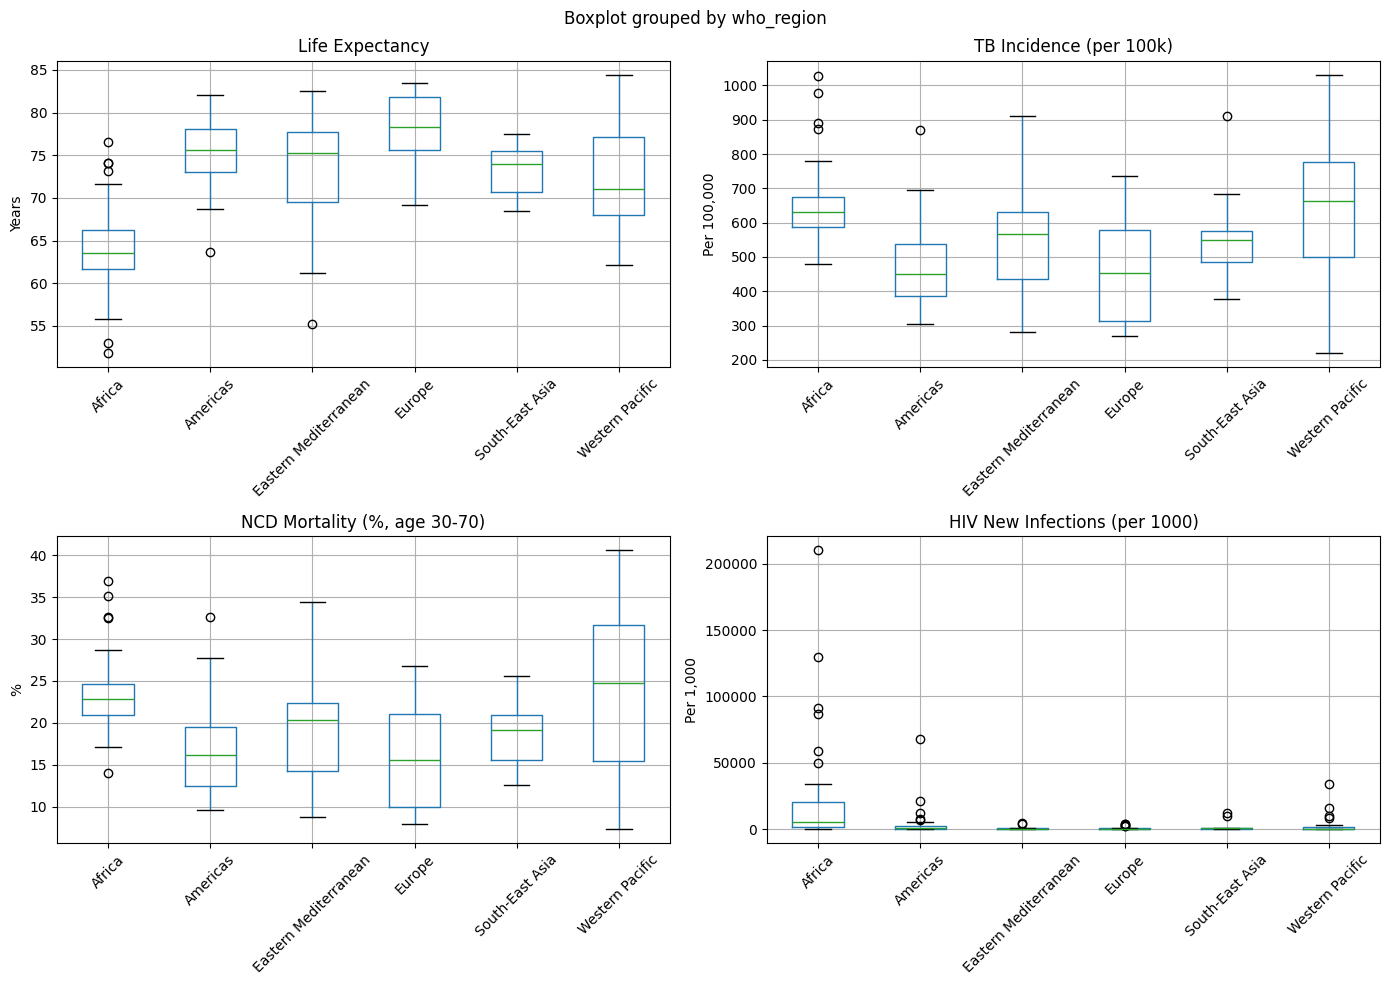

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Disease Burden Indicators by WHO Region (2019)", fontsize=14, fontweight="bold")

region_order = df_2019.groupby("who_region")["life_expectancy"].median().sort_values().index
df_2019.boxplot(column="life_expectancy", by="who_region", ax=axes[0, 0], vert=True)
axes[0, 0].set_title("Life Expectancy")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Years")
axes[0, 0].tick_params(axis="x", rotation=45)
df_2019.boxplot(column="tb_incidence_per100k", by="who_region", ax=axes[0, 1], vert=True)
axes[0, 1].set_title("TB Incidence (per 100k)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Per 100,000")
axes[0, 1].tick_params(axis="x", rotation=45)
df_2019.boxplot(column="ncd_mortality_pct", by="who_region", ax=axes[1, 0], vert=True)
axes[1, 0].set_title("NCD Mortality (%, age 30-70)")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("%")
axes[1, 0].tick_params(axis="x", rotation=45)
df_2019.boxplot(column="hiv_new_infections_per1000", by="who_region", ax=axes[1, 1], vert=True)
axes[1, 1].set_title("HIV New Infections (per 1000)")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Per 1,000")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("disease_burden_by_region_2019.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 GDP vs Disease Burden (2019)

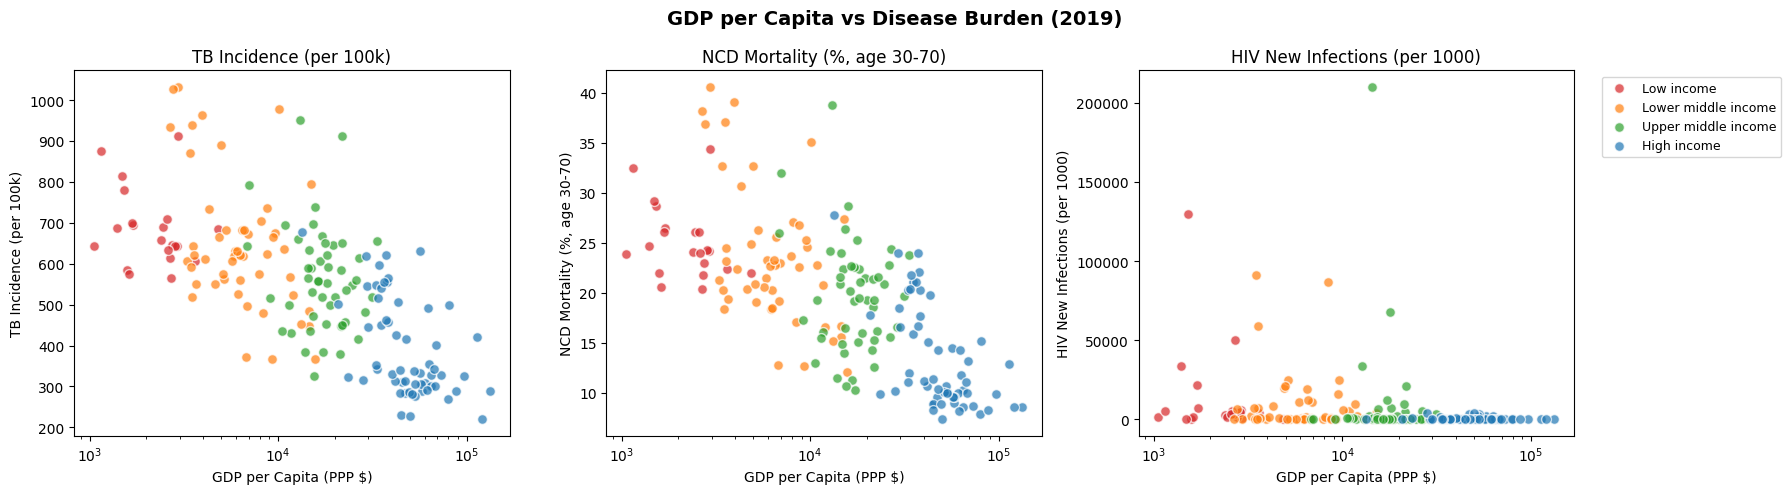

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GDP per Capita vs Disease Burden (2019)", fontsize=14, fontweight="bold")

colors = {"Low income": "#d62728", "Lower middle income": "#ff7f0e", 
          "Upper middle income": "#2ca02c", "High income": "#1f77b4"}

for ax, (col, label) in zip(axes, [
    ("tb_incidence_per100k", "TB Incidence (per 100k)"),
    ("ncd_mortality_pct", "NCD Mortality (%, age 30-70)"),
    ("hiv_new_infections_per1000", "HIV New Infections (per 1000)")
]):
    for group, color in colors.items():
        mask = df_2019["income_group"] == group
        ax.scatter(df_2019.loc[mask, "gdp_per_capita_ppp"], 
                   df_2019.loc[mask, col],
                   c=color, label=group, alpha=0.7, edgecolors="white", s=50)
    ax.set_xlabel("GDP per Capita (PPP $)")
    ax.set_ylabel(label)
    ax.set_xscale("log")
    ax.set_title(label)

axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("gdp_vs_disease_burden_2019.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.4 Epidemiological Transition Over Time by Income Group

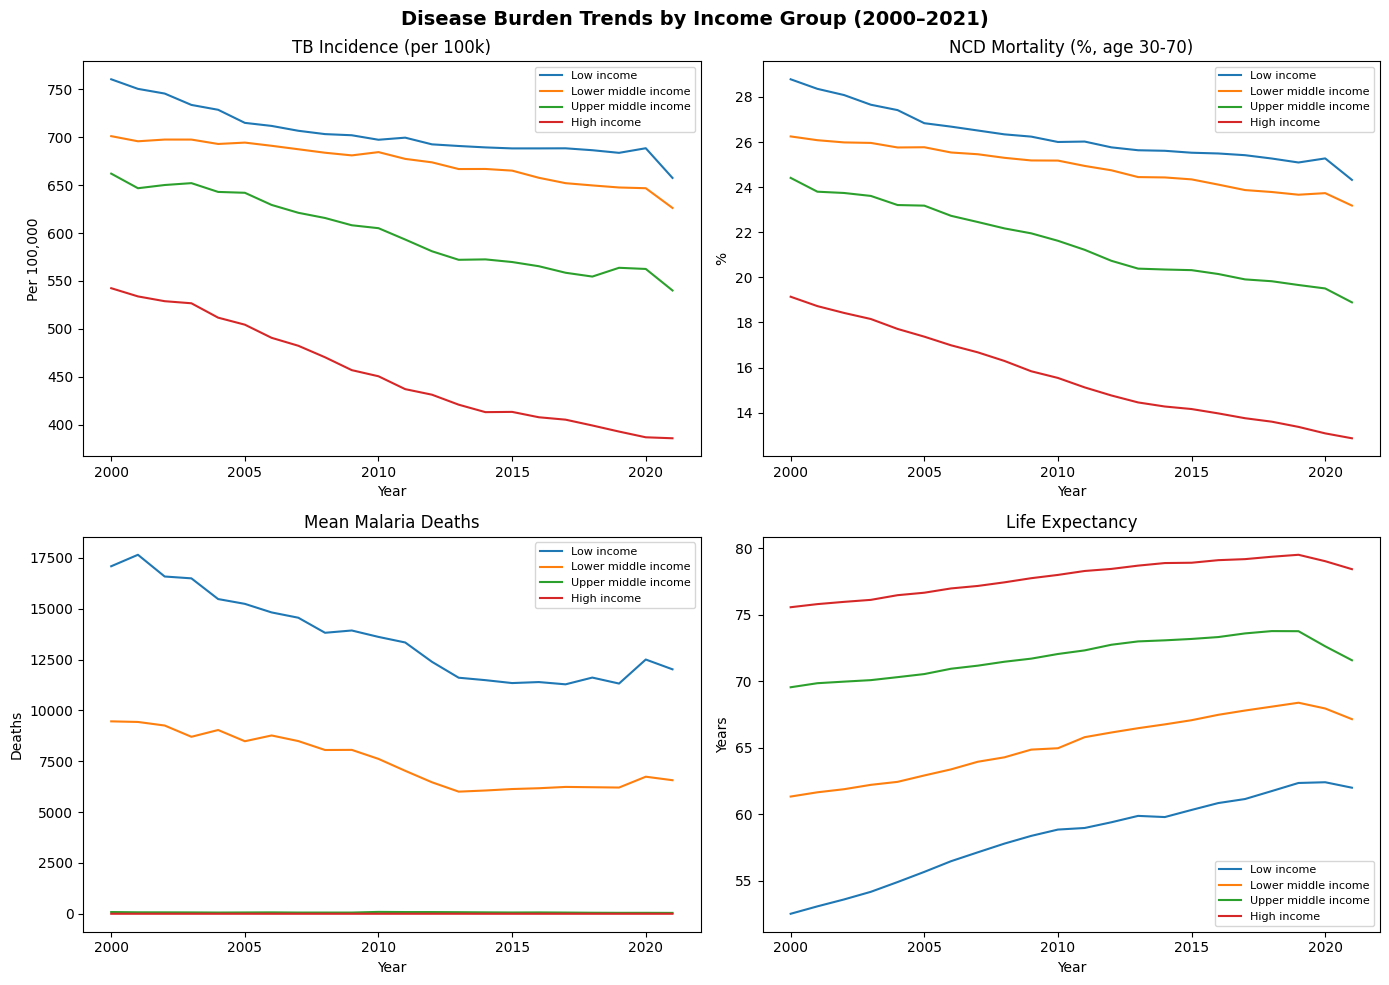

In [23]:
# Track how infectious vs NCD burden shifts over time by income group
trends = (df.groupby(["year", "income_group"])[["tb_incidence_per100k", "ncd_mortality_pct", 
                                                  "malaria_deaths", "life_expectancy"]]
          .mean().reset_index())

income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Disease Burden Trends by Income Group (2000–2021)", fontsize=14, fontweight="bold")

for group in income_order:
    subset = trends[trends["income_group"] == group]
    axes[0, 0].plot(subset["year"], subset["tb_incidence_per100k"], label=group)
    axes[0, 1].plot(subset["year"], subset["ncd_mortality_pct"], label=group)
    axes[1, 0].plot(subset["year"], subset["malaria_deaths"], label=group)
    axes[1, 1].plot(subset["year"], subset["life_expectancy"], label=group)

axes[0, 0].set_title("TB Incidence (per 100k)")
axes[0, 0].set_ylabel("Per 100,000")
axes[0, 1].set_title("NCD Mortality (%, age 30-70)")
axes[0, 1].set_ylabel("%")
axes[1, 0].set_title("Mean Malaria Deaths")
axes[1, 0].set_ylabel("Deaths")
axes[1, 1].set_title("Life Expectancy")
axes[1, 1].set_ylabel("Years")

for ax in axes.flat:
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("disease_trends_by_income_2000_2021.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
print(df_2019.nlargest(10, "hiv_new_infections_per1000")[
    ["country_name", "hiv_new_infections_per1000", "income_group"]])

          country_name  hiv_new_infections_per1000         income_group
4885      South Africa                    210000.0  Upper middle income
3019        Mozambique                    130000.0           Low income
4585          Tanzania                     91000.0  Lower middle income
3216           Nigeria                     87000.0  Lower middle income
594             Brazil                     68000.0  Upper middle income
4910            Zambia                     59000.0  Lower middle income
4610            Uganda                     50000.0           Low income
894   Congo, Dem. Rep.                     34000.0           Low income
1969         Indonesia                     34000.0  Upper middle income
44              Angola                     25000.0  Lower middle income


In [25]:
df["hiv_new_infections_per1000"] = (df["hiv_new_infections_per1000"] / df["population"]) * 1000
df["malaria_deaths_per100k"] = (df["malaria_deaths"] / df["population"]) * 100000
df_2019 = df[df["year"] == 2019].copy()
print(df_2019.nlargest(10, "hiv_new_infections_per1000")[
    ["country_name", "hiv_new_infections_per1000", "population"]].round(2))

      country_name  hiv_new_infections_per1000  population
4235      Eswatini                        5.34   1179874.0
3019    Mozambique                        4.35  29884380.0
4885  South Africa                        3.52  59587885.0
4910        Zambia                        3.19  18513839.0
694       Botswana                        3.13   2332083.0
2594       Lesotho                        2.99   2209405.0
919    Congo, Rep.                        1.96   5616661.0
3166       Namibia                        1.92   2650494.0
4585      Tanzania                        1.54  59174891.0
4935      Zimbabwe                        1.38  15271368.0


### 6.5 GDP vs Disease Burden — Corrected (2019)

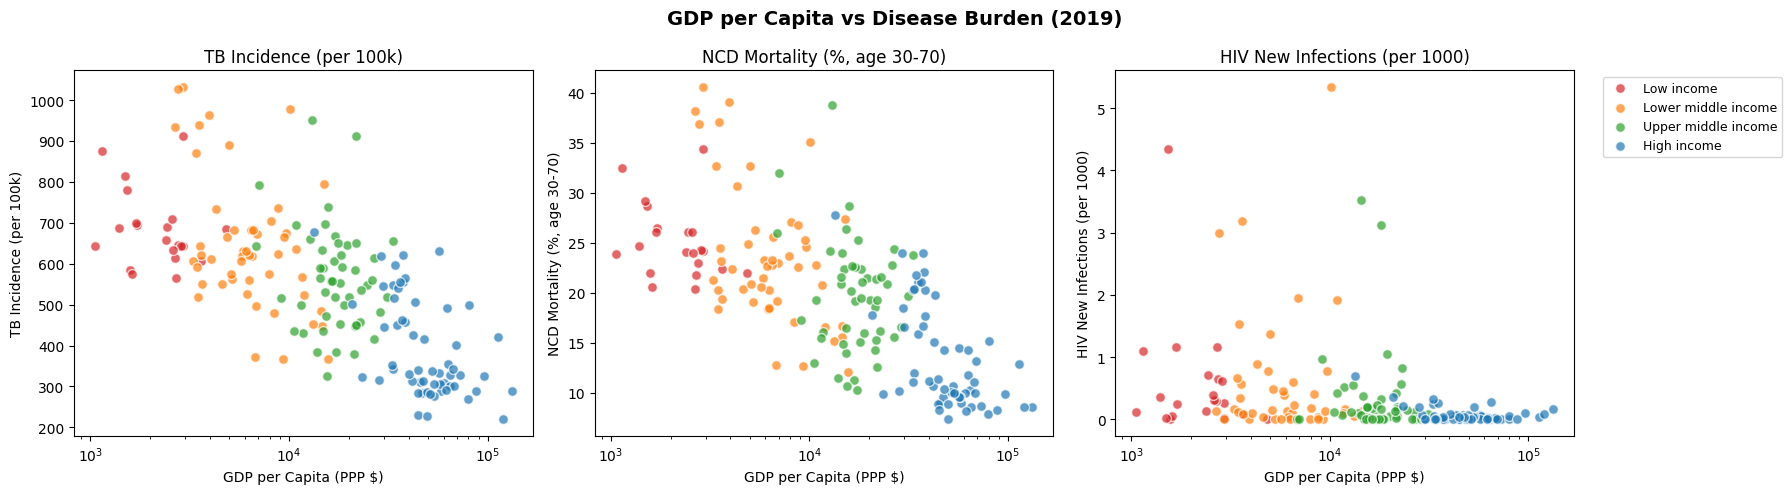

In [26]:
df_2019 = df[df["year"] == 2019].copy()
income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
df_2019["income_group"] = pd.Categorical(df_2019["income_group"], categories=income_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("GDP per Capita vs Disease Burden (2019)", fontsize=14, fontweight="bold")

colors = {"Low income": "#d62728", "Lower middle income": "#ff7f0e", 
          "Upper middle income": "#2ca02c", "High income": "#1f77b4"}

for ax, (col, label) in zip(axes, [
    ("tb_incidence_per100k", "TB Incidence (per 100k)"),
    ("ncd_mortality_pct", "NCD Mortality (%, age 30-70)"),
    ("hiv_new_infections_per1000", "HIV New Infections (per 1000)")
]):
    for group, color in colors.items():
        mask = df_2019["income_group"] == group
        ax.scatter(df_2019.loc[mask, "gdp_per_capita_ppp"], 
                   df_2019.loc[mask, col],
                   c=color, label=group, alpha=0.7, edgecolors="white", s=50)
    ax.set_xlabel("GDP per Capita (PPP $)")
    ax.set_ylabel(label)
    ax.set_xscale("log")
    ax.set_title(label)

axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("gdp_vs_disease_corrected_2019.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.6 Infectious vs NCD Burden Ratio by Income Group

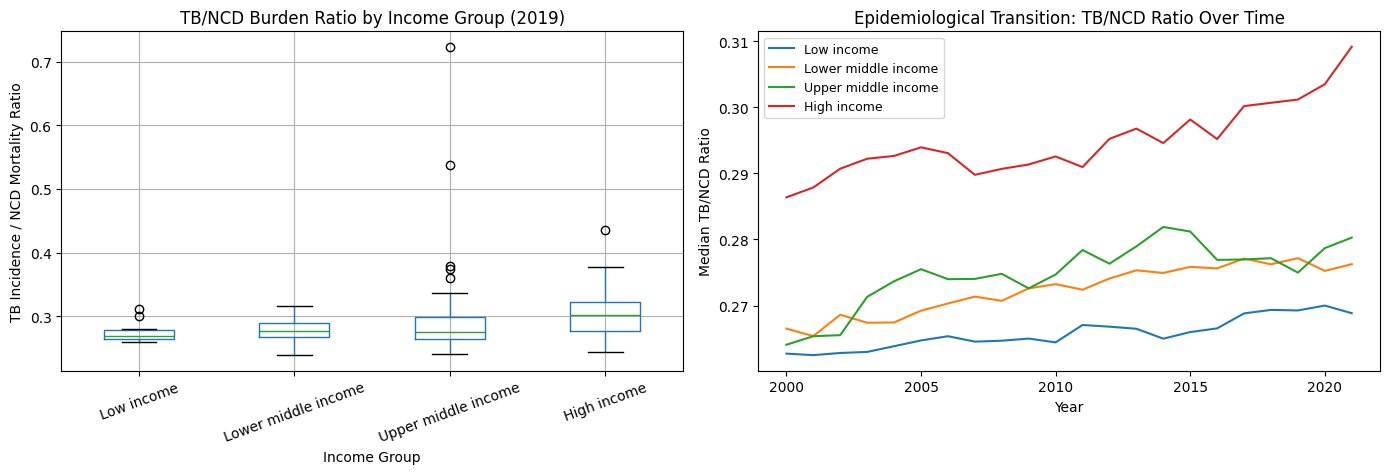

In [27]:
df["infectious_ncd_ratio"] = df["tb_incidence_per100k"] / (df["ncd_mortality_pct"] * 100)

df_2019 = df[df["year"] == 2019].copy()
df_2019["income_group"] = pd.Categorical(df_2019["income_group"], categories=income_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_2019.boxplot(column="infectious_ncd_ratio", by="income_group", ax=axes[0])
axes[0].set_title("TB/NCD Burden Ratio by Income Group (2019)")
axes[0].set_xlabel("Income Group")
axes[0].set_ylabel("TB Incidence / NCD Mortality Ratio")
axes[0].tick_params(axis="x", rotation=20)
plt.sca(axes[0])
plt.title("TB/NCD Burden Ratio by Income Group (2019)")
ratio_trend = df.groupby(["year", "income_group"])["infectious_ncd_ratio"].median().reset_index()
for group in income_order:
    subset = ratio_trend[ratio_trend["income_group"] == group]
    axes[1].plot(subset["year"], subset["infectious_ncd_ratio"], label=group)
axes[1].set_title("Epidemiological Transition: TB/NCD Ratio Over Time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median TB/NCD Ratio")
axes[1].legend(fontsize=9)

fig.suptitle("")
plt.tight_layout()
plt.savefig("infectious_ncd_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.7 Correlation Heatmap

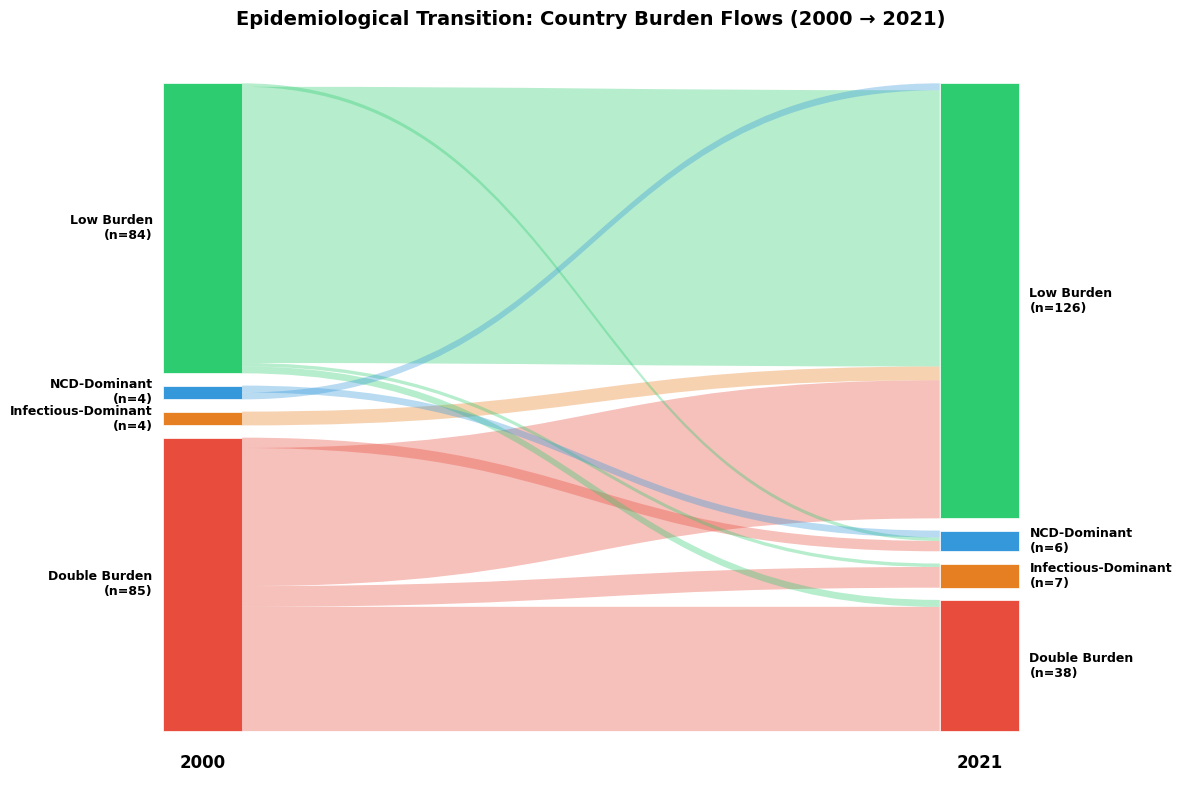

In [28]:
import plotly.graph_objects as go

df_2019 = df[df["year"] == 2019].copy()

df_2019["tb_burden"] = pd.qcut(df_2019["tb_incidence_per100k"], q=3, labels=["Low TB", "Medium TB", "High TB"])
income_groups = ["Low income", "Lower middle income", "Upper middle income", "High income"]
burden_levels = ["Low TB", "Medium TB", "High TB"]
regions = sorted(df_2019["who_region"].unique().tolist())

all_nodes = income_groups + burden_levels + regions
node_indices = {name: i for i, name in enumerate(all_nodes)}
sources1, targets1, values1 = [], [], []
for inc in income_groups:
    for bur in burden_levels:
        count = len(df_2019[(df_2019["income_group"] == inc) & (df_2019["tb_burden"] == bur)])
        if count > 0:
            sources1.append(node_indices[inc])
            targets1.append(node_indices[bur])
            values1.append(count)
sources2, targets2, values2 = [], [], []
for bur in burden_levels:
    for reg in regions:
        count = len(df_2019[(df_2019["tb_burden"] == bur) & (df_2019["who_region"] == reg)])
        if count > 0:
            sources2.append(node_indices[bur])
            targets2.append(node_indices[reg])
            values2.append(count)
node_colors = (
    ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"] +  # income
    ["#ffcccc", "#ffffcc", "#ccffcc"] +               # burden
    ["#a6cee3", "#b2df8a", "#fb9a99", "#fdbf6f", "#cab2d6", "#ffff99"]  # regions
)

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20, thickness=20,
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=sources1 + sources2,
        target=targets1 + targets2,
        value=values1 + values2,
        color="rgba(200, 200, 200, 0.4)"
    )
))

fig.update_layout(
    title_text="Income Group → TB Burden Level → WHO Region (2019)",
    font_size=12,
    width=900, height=500
)

fig.write_image("sankey_income_burden_region_2019.png", scale=2)
fig.show()

### 6.8 Regional Disease Profile Comparison (2019)

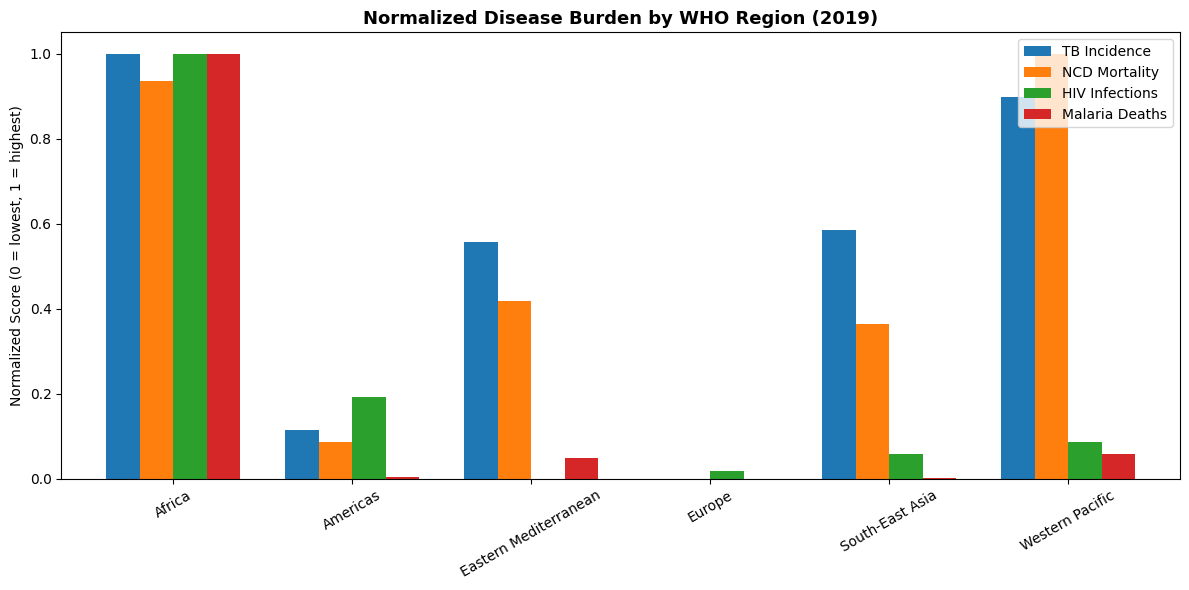

In [33]:
df_2019 = df[df["year"] == 2019].copy()

region_means = df_2019.groupby("who_region")[
    ["tb_incidence_per100k", "ncd_mortality_pct", "hiv_new_infections_per1000", "malaria_deaths_per100k"]
].mean()

region_norm = (region_means - region_means.min()) / (region_means.max() - region_means.min())
region_norm.columns = ["TB Incidence", "NCD Mortality", "HIV Infections", "Malaria Deaths"]

fig, ax = plt.subplots(figsize=(12, 6))
region_norm.plot(kind="bar", ax=ax, width=0.75)
ax.set_title("Normalized Disease Burden by WHO Region (2019)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Normalized Score (0 = lowest, 1 = highest)")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("regional_disease_profile_2019.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.9 Statistical Tests

In [30]:
from scipy import stats

df_2019 = df[df["year"] == 2019].copy()

print("One-Way ANOVA across Income Groups (2019)")
print("=" * 60)

test_cols = {
    "life_expectancy": "Life Expectancy",
    "tb_incidence_per100k": "TB Incidence",
    "ncd_mortality_pct": "NCD Mortality",
    "hiv_new_infections_per1000": "HIV Infections",
    "malaria_deaths_per100k": "Malaria Deaths"
}

income_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]

for col, label in test_cols.items():
    group_data = [df_2019[df_2019["income_group"] == g][col].dropna() for g in income_order]
    stat, p = stats.f_oneway(*group_data)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {label:30s}  F = {stat:8.2f},  p = {p:.2e}  {sig}")

print("\n*** p < 0.001,  ** p < 0.01,  * p < 0.05,  ns = not significant")

One-Way ANOVA across Income Groups (2019)
  Life Expectancy                 F =    98.39,  p = 2.80e-37  ***
  TB Incidence                    F =    43.04,  p = 7.39e-21  ***
  NCD Mortality                   F =    38.43,  p = 4.15e-19  ***
  HIV Infections                  F =     4.67,  p = 3.66e-03  **
  Malaria Deaths                  F =    48.21,  p = 9.92e-23  ***

*** p < 0.001,  ** p < 0.01,  * p < 0.05,  ns = not significant


In [31]:
print("Pearson Correlations: GDP per Capita vs Disease Burden (2019)")
print("=" * 60)

for col, label in test_cols.items():
    valid = df_2019[["gdp_per_capita_ppp", col]].dropna()
    r, p = stats.pearsonr(valid["gdp_per_capita_ppp"], valid[col])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {label:30s}  r = {r:+.3f},  p = {p:.2e}  {sig}")

Pearson Correlations: GDP per Capita vs Disease Burden (2019)
  Life Expectancy                 r = +0.708,  p = 2.44e-28  ***
  TB Incidence                    r = -0.653,  p = 4.91e-23  ***
  NCD Mortality                   r = -0.651,  p = 7.28e-23  ***
  HIV Infections                  r = -0.244,  p = 1.04e-03  **
  Malaria Deaths                  r = -0.356,  p = 1.05e-06  ***


In [32]:
print("Independent t-test: Low Income vs High Income (2019)")
print("=" * 60)

low = df_2019[df_2019["income_group"] == "Low income"]
high = df_2019[df_2019["income_group"] == "High income"]

for col, label in test_cols.items():
    stat, p = stats.ttest_ind(low[col].dropna(), high[col].dropna(), equal_var=False)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    low_mean = low[col].mean()
    high_mean = high[col].mean()
    print(f"  {label:30s}  Low mean = {low_mean:8.1f},  High mean = {high_mean:8.1f},  p = {p:.2e}  {sig}")

Independent t-test: Low Income vs High Income (2019)
  Life Expectancy                 Low mean =     62.3,  High mean =     79.5,  p = 2.47e-17  ***
  TB Incidence                    Low mean =    683.6,  High mean =    392.8,  p = 6.83e-15  ***
  NCD Mortality                   Low mean =     25.1,  High mean =     13.4,  p = 2.61e-15  ***
  HIV Infections                  Low mean =      0.6,  High mean =      0.1,  p = 2.47e-02  *
  Malaria Deaths                  Low mean =     51.7,  High mean =      0.1,  p = 2.52e-06  ***
